<a href="https://colab.research.google.com/github/rahu2004/CHAT_AI_TOOLS/blob/main/AI_Content_Studio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q \
openai \
gradio \
transformers \
diffusers \
accelerate \
torch \
moviepy \
gtts \
Pillow

AI Text Generator

In [2]:
from transformers import AutoTokenizer
from transformers import AutoModelForSeq2SeqLM

model_name = "google/flan-t5-large"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

prompt = """
Task:
Create professional marketing content for an AI startup.

Generate:
1. Instagram Caption
2. LinkedIn Post
3. YouTube Title
4. Marketing Slogan

Format the answer clearly.
"""

inputs = tokenizer(
    prompt,
    return_tensors="pt",
    truncation=True
)

outputs = model.generate(
    **inputs,
    max_new_tokens=256,
    num_beams=5,
    early_stopping=True,
    no_repeat_ngram_size=2
)

response = tokenizer.decode(
    outputs[0],
    skip_special_tokens=True
)

print(response)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/558 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


1. Instagram Caption 2. LinkedIn Post 3. YouTube Title 4. Marketing Slogan


AI Image Generator

In [3]:
from diffusers import StableDiffusionPipeline
import torch

pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16
)

pipe = pipe.to("cuda")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  0%|          | 0/50 [00:00<?, ?it/s]

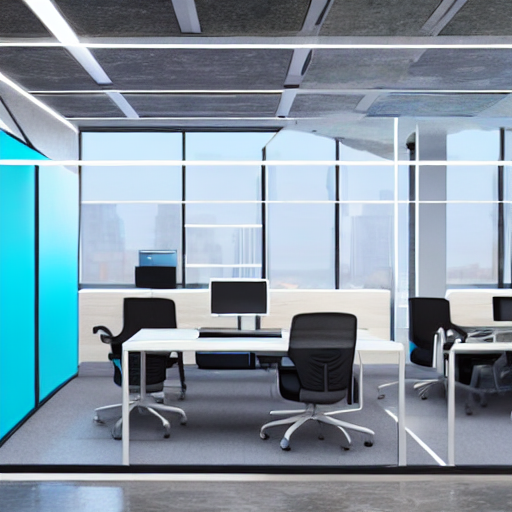

In [4]:
prompt = "Futuristic AI startup office"

image = pipe(prompt).images[0]

image.save("generated_image.png")

image

AI Voice Generator

In [5]:
from gtts import gTTS

text = "Welcome to the AI Content Studio"

tts = gTTS(text)

tts.save("voice.mp3")

print("Voice Generated")

Voice Generated


AI Video Generator

In [6]:
from moviepy.editor import *

image_clip = ImageClip("generated_image.png")

audio_clip = AudioFileClip("voice.mp3")

video = image_clip.set_duration(audio_clip.duration)

video = video.set_audio(audio_clip)

video.write_videofile(
    "final_video.mp4",
    fps=24
)

Moviepy - Building video final_video.mp4.
MoviePy - Writing audio in final_videoTEMP_MPY_wvf_snd.mp3


MoviePy - Done.
Moviepy - Writing video final_video.mp4



Moviepy - Done !
Moviepy - video ready final_video.mp4


In [7]:
from google.colab import files

files.download("final_video.mp4")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

AI Branding Generator

In [8]:
branding_prompt = """
You are a branding expert.

Generate:
1. Brand Name
2. Marketing Slogan
3. Brand Mission

for an AI marketing company.

Format clearly.
"""

inputs = tokenizer(
    branding_prompt,
    return_tensors="pt",
    truncation=True
)

outputs = model.generate(
    **inputs,
    max_new_tokens=200,
    num_beams=5,
    no_repeat_ngram_size=2,
    early_stopping=True
)

branding_response = tokenizer.decode(
    outputs[0],
    skip_special_tokens=True
)

print(branding_response)

2. Marketing Slogan 3. Brand Mission


AI Marketing Generator

In [10]:
marketing_prompt = """
Create:
- Instagram caption
- LinkedIn post
- YouTube title
- Hashtags

for a new AI productivity app
"""

inputs = tokenizer(
    marketing_prompt,
    return_tensors="pt",
    truncation=True
)

outputs = model.generate(
    **inputs,
    max_new_tokens=256,
    num_beams=5,
    early_stopping=True,
    no_repeat_ngram_size=2
)

response = tokenizer.decode(
    outputs[0],
    skip_special_tokens=True
)

print(response)

Hashtags for a new AI productivity app


Build Multi-Modal Gradio UI

In [20]:
import gradio as gr

def generate_ai_content(prompt):

    return f"""
Startup Idea: {prompt}

Startup Name:
GreenBasket AI

Instagram Caption:
Fresh vegetables delivered smarter with AI 🌱

LinkedIn Post:
Our AI-powered platform connects farmers and customers for smarter vegetable delivery.

YouTube Title:
How AI is Transforming Vegetable Delivery Startups

Marketing Slogan:
Freshness Powered by AI

Hashtags:
#AI #Startup #SmartFarming #Vegetables
"""

with gr.Blocks() as demo:

    gr.Markdown("# 🚀 AI Content Studio")

    prompt_input = gr.Textbox(
        lines=4,
        label="Enter Startup Idea",
        placeholder="Example: Vegetable delivery startup"
    )

    generate_button = gr.Button("Generate Content")

    output_box = gr.Textbox(
        lines=20,
        label="AI Generated Output"
    )

    generate_button.click(
        fn=generate_ai_content,
        inputs=prompt_input,
        outputs=output_box
    )

demo.launch(
    share=True,
    debug=True
)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://4d353db3aad73fcba6.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7861 <> https://4d353db3aad73fcba6.gradio.live


AI Assistant Chatbot

In [23]:
!pip install -q gradio transformers sentencepiece

import gradio as gr
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

model_name = "google/flan-t5-base"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

def ai_chatbot(message):

    prompt = f"""
You are a helpful AI assistant.

Answer this professionally:

{message}
"""

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512
    )

    outputs = model.generate(
        **inputs,
        max_new_tokens=200,
        temperature=0.7,
        do_sample=True
    )

    response = tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )

    return response

with gr.Blocks() as demo:

    gr.Markdown("# 🤖 AI Assistant Chatbot")

    user_input = gr.Textbox(
        label="Enter Your Message",
        placeholder="Ask anything..."
    )

    submit_btn = gr.Button("Send")

    output = gr.Textbox(
        label="AI Response",
        lines=10
    )

    submit_btn.click(
        fn=ai_chatbot,
        inputs=user_input,
        outputs=output
    )

demo.launch(
    share=True,
    debug=True
)

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://2331af20e7a03387fc.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7861 <> https://2331af20e7a03387fc.gradio.live


Save Outputs Automatically

In [24]:
import os

os.makedirs("outputs", exist_ok=True)

image.save("outputs/generated_image.png")